In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("C:\\Users\\user\\OneDrive\\Desktop\\financial_regime_clasification\\data\\raw\\raw.csv")

# Check missing values in prediction columns
pred_cols = ['probability', '0.6 percent prediction', '1 percent prediction', '1.5 percent prediction']

print("="*60)
print("MISSING DATA ANALYSIS")
print("="*60)

# 1. Count missing per column
print("\n1. Missing values per column:")
for col in pred_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        total = len(df)
        pct = (missing/total)*100
        print(f"   {col:30} : {missing:4} / {total:4} ({pct:5.2f}%)")
    else:
        print(f"   {col:30} : Column not found")

# 2. Check if missing happens in same rows
if all(col in df.columns for col in pred_cols):
    missing_pattern = df[pred_cols].isnull().all(axis=1)
    all_missing = missing_pattern.sum()
    print(f"\n2. Rows where ALL prediction columns are missing: {all_missing} ({all_missing/len(df)*100:.2f}%)")
    
    # Check rows with partial missing
    any_missing = df[pred_cols].isnull().any(axis=1).sum()
    print(f"   Rows with ANY missing prediction: {any_missing} ({any_missing/len(df)*100:.2f}%)")
    
    # Show sample of missing pattern
    print("\n3. Sample of rows with missing data (first 5):")
    missing_rows = df[df[pred_cols].isnull().any(axis=1)]
    if len(missing_rows) > 0:
        print(missing_rows[pred_cols].head())
    else:
        print("   No missing rows found!")

# 4. Check temporal pattern 
if 'date' in df.columns:
    print("\n4. Temporal pattern of missing data:")
    df['date'] = pd.to_datetime(df['date'])
    df_sorted = df.sort_values('date')
    
    # Check if missing values are at beginning, end, or scattered
    first_quarter = len(df_sorted) // 4
    second_quarter = first_quarter * 2
    third_quarter = first_quarter * 3
    
    segments = [
        ('First 25%', df_sorted.iloc[:first_quarter]),
        ('Second 25%', df_sorted.iloc[first_quarter:second_quarter]),
        ('Third 25%', df_sorted.iloc[second_quarter:third_quarter]),
        ('Last 25%', df_sorted.iloc[third_quarter:])
    ]
    
    for segment_name, segment_df in segments:
        missing_count = segment_df[pred_cols].isnull().any(axis=1).sum()
        total_count = len(segment_df)
        print(f"   {segment_name:15} : {missing_count:3}/{total_count:3} ({missing_count/total_count*100:.1f}% missing)")

# 5. Check forward regime distribution in missing vs non-missing rows
if 'forward regime' in df.columns:
    print("\n5. Forward regime distribution:")
    df_with_pred = df[~df[pred_cols[0]].isnull()] if pred_cols[0] in df.columns else df
    df_without_pred = df[df[pred_cols[0]].isnull()] if pred_cols[0] in df.columns else pd.DataFrame()
    
    if len(df_without_pred) > 0:
        print(" Rows WITH predictions:")
        print(df_with_pred['forward regime'].value_counts(normalize=True))
        print("\n Rows WITHOUT predictions:")
        print(df_without_pred['forward regime'].value_counts(normalize=True))

print("\n" + "=" * 60)
print("RECOMMENDATION BASED ON PATTERNS:")
print("=" * 60)

# recommendation
if all(col in df.columns for col in pred_cols):
    missing_pct = df[pred_cols[0]].isnull().mean()
    
    if missing_pct < 0.05:
        print("Low missing rate (<5%) → Use 'drop' strategy")
    elif missing_pct > 0.30:
        print("High missing rate (>30%) → Use 'fill_zero' or 'fill_forward'")
    else:
        print("Moderate missing rate → Check temporal pattern above")
        
    # Check if missing is at the end of time series
    if 'date' in df.columns and missing_pct > 0:
        last_20pct = df_sorted.iloc[-int(len(df_sorted)*0.2):]
        if last_20pct[pred_cols[0]].isnull().all():
            print("Missing only at the END of time series → Use 'fill_forward' to propagate last known values")
        elif last_20pct[pred_cols[0]].isnull().any():
            print("Missing values are scattered → Use 'fill_median' or 'fill_zero'")

MISSING DATA ANALYSIS

1. Missing values per column:
   probability                    :  936 / 2942 (31.82%)
   0.6 percent prediction         : 1051 / 2942 (35.72%)
   1 percent prediction           : 1051 / 2942 (35.72%)
   1.5 percent prediction         : 1051 / 2942 (35.72%)

2. Rows where ALL prediction columns are missing: 936 (31.82%)
   Rows with ANY missing prediction: 1051 (35.72%)

3. Sample of rows with missing data (first 5):
    probability  0.6 percent prediction  1 percent prediction  \
1           NaN                     NaN                   NaN   
4          91.0                     NaN                   NaN   
15          NaN                     NaN                   NaN   
17          NaN                     NaN                   NaN   
18          NaN                     NaN                   NaN   

    1.5 percent prediction  
1                      NaN  
4                      NaN  
15                     NaN  
17                     NaN  
18                  

CLASS IMBALANCE ANALYSIS

1. Raw class distribution:
   range        : 1946 rows (66.15%)
   upward       :  551 rows (18.73%)
   downward     :  445 rows (15.13%)

2. Imbalance metrics:
   Majority class size: 1946
   Minority class size: 445
   Imbalance ratio: 4.37:1
  MODERATE IMBALANCE (3-10:1) - Use class weights/sampling

3. Distribution after handling missing data:
   After dropping missing (keep 1891 rows):
      range        : 1239 (65.52%)
      upward       :  383 (20.25%)
      downward     :  269 (14.23%)

   After filling missing (keep 2942 rows):
      range        : 1946 (66.15%)
      upward       :  551 (18.73%)
      downward     :  445 (15.13%)

4. Feature means by class (key indicators):

   past_ret_1h:
      range        : -0.000120
      downward     : 0.000043
      upward       : 0.000069

   past_ret_2h:
      range        : -0.000187
      downward     : 0.000037
      upward       : -0.000007

   past_ret_4h:
      range        : -0.000338
      downward  

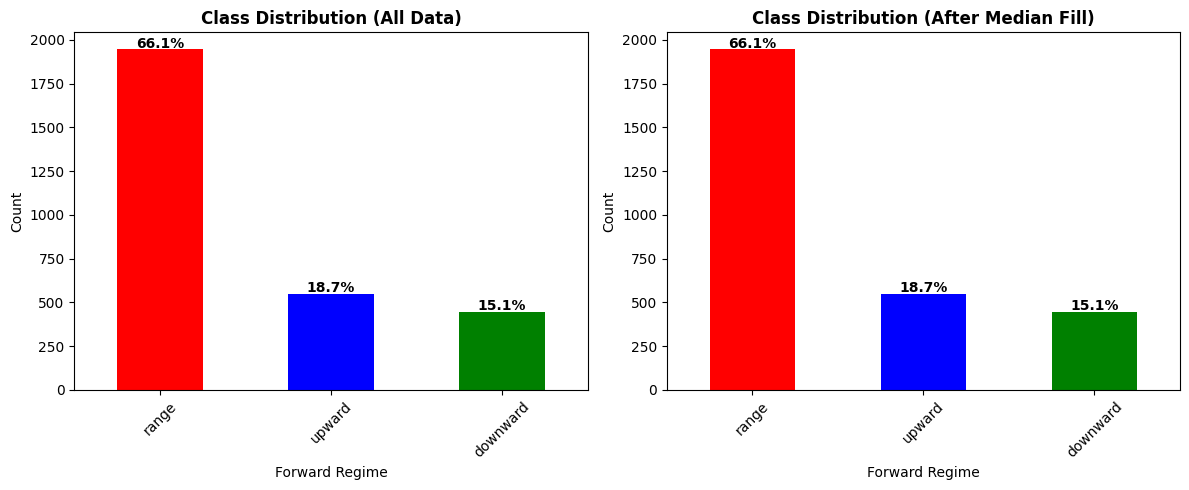


COMPUTED CLASS WEIGHTS FOR YOUR DATA

Balanced class weights (inverse frequency):
   downward     : 2.2037
   range        : 0.5039
   upward       : 1.7798

MODEL FEASIBILITY CHECK
  OK: Minority class has 445 samples
   - All proposed models are feasible
   - TCN may work with sequence_length <= 5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Load your data
df = pd.read_csv('C:\\Users\\user\\OneDrive\\Desktop\\financial_regime_clasification\\data\\raw\\raw.csv')

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# 1. Basic class distribution
target_col = 'forward regime'
print(f"\n1. Raw class distribution:")
class_counts = df[target_col].value_counts()
class_percentages = df[target_col].value_counts(normalize=True) * 100

for class_name, count, pct in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f"   {class_name:12} : {count:4} rows ({pct:5.2f}%)")

# 2. Imbalance ratio
majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count
print(f"\n2. Imbalance metrics:")
print(f"   Majority class size: {majority_count}")
print(f"   Minority class size: {minority_count}")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")

# 3. Classification difficulty assessment
if imbalance_ratio > 10:
    print("  SEVERE IMBALANCE (>10:1) - Use advanced techniques")
elif imbalance_ratio > 3:
    print("  MODERATE IMBALANCE (3-10:1) - Use class weights/sampling")
else:
    print("  MILD IMBALANCE (<3:1) - Standard techniques may work")

# 4. Check distribution AFTER removing missing data
print(f"\n3. Distribution after handling missing data:")
# Strategy 1: Drop missing
df_dropped = df.dropna(subset=['probability', '0.6 percent prediction', 
                               '1 percent prediction', '1.5 percent prediction'])
print(f"   After dropping missing (keep {len(df_dropped)} rows):")
for class_name, count in df_dropped[target_col].value_counts().items():
    pct = count/len(df_dropped)*100
    print(f"      {class_name:12} : {count:4} ({pct:5.2f}%)")

# Strategy 2: Fill missing (use all data)
df_filled = df.copy()
pred_cols = ['probability', '0.6 percent prediction', '1 percent prediction', '1.5 percent prediction']
for col in pred_cols:
    if col in df_filled.columns:
        df_filled[col] = df_filled[col].fillna(df_filled[col].median())
print(f"\n   After filling missing (keep {len(df_filled)} rows):")
for class_name, count in df_filled[target_col].value_counts().items():
    pct = count/len(df_filled)*100
    print(f"      {class_name:12} : {count:4} ({pct:5.2f}%)")

# 5. Per-class feature statistics (to understand class separability)
print(f"\n4. Feature means by class (key indicators):")
feature_cols = ['past_ret_1h', 'past_ret_2h', 'past_ret_4h', 'past_ret_8h', 'past_ret_16h']
for col in feature_cols:
    if col in df.columns:
        print(f"\n   {col}:")
        for regime in df[target_col].unique():
            mean_val = df[df[target_col] == regime][col].mean()
            print(f"      {regime:12} : {mean_val:.6f}")

# 6. Recommended strategies
print("\n" + "=" * 60)
print("RECOMMENDED IMBALANCE HANDLING STRATEGIES")
print("=" * 60)

if imbalance_ratio > 5:
    print("\n SEVERE IMBALANCE DETECTED - Use MULTIPLE strategies:")
    print("   1. Class weights (compute_weight='balanced')")
    print("   2. SMOTE or ADASYN oversampling")
    print("   3. Focus on precision/recall for minority class")
    print("   4. Use metrics: F1-score, ROC-AUC, PR-AUC")
    print("\n   For YOUR models:")
    print("   - CatBoost: class_weights parameter")
    print("   - LightGBM: is_unbalance=True or scale_pos_weight")
    print("   - RandomForest: class_weight='balanced_subsample'")
else:
    print("\n MILD IMBALANCE - Use simple strategies:")
    print("   1. Class weights in model parameters")
    print("   2. Stratified train-test split")

# 7. Interactive recommendation based on sample
print("\n" + "=" * 60)
print("STRATEGY FOR YOUR SPECIFIC CASE (31.8% missing, imbalanced)")
print("=" * 60)

if 0.30 < missing_pct < 0.40 and imbalance_ratio > 3:
    print("\n  You have BOTH high missingness AND class imbalance!")
    print("\n RECOMMENDED PIPELINE:")
    print("   1. DO NOT drop missing rows (would lose 936 rows + worsen imbalance)")
    print("   2. Use 'fill_median' for prediction columns (preserves class distribution)")
    print("   3. Apply class weights based on filled data")
    print("   4. Use stratified k-fold cross-validation")
    print("   5. Evaluate with precision-recall curves (not just ROC)")

# 8. Visual imbalance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before handling missing
ax1 = axes[0]
class_counts.plot(kind='bar', ax=ax1, color=['red', 'blue', 'green'])
ax1.set_title('Class Distribution (All Data)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Forward Regime')
ax1.set_ylabel('Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
# Add percentage labels
for i, (class_name, count) in enumerate(class_counts.items()):
    pct = count/len(df)*100
    ax1.text(i, count + 10, f'{pct:.1f}%', ha='center', fontweight='bold')

# After filling missing
ax2 = axes[1]
filled_counts = df_filled[target_col].value_counts()
filled_counts.plot(kind='bar', ax=ax2, color=['red', 'blue', 'green'])
ax2.set_title('Class Distribution (After Median Fill)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Forward Regime')
ax2.set_ylabel('Count')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
for i, (class_name, count) in enumerate(filled_counts.items()):
    pct = count/len(df_filled)*100
    ax2.text(i, count + 10, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 9. Compute optimal class weights
print("\n" + "=" * 60)
print("COMPUTED CLASS WEIGHTS FOR YOUR DATA")
print("=" * 60)

# Method 1: Balanced weights
classes = np.unique(df_filled[target_col])
balanced_weights = compute_class_weight('balanced', classes=classes, y=df_filled[target_col])
weight_dict = dict(zip(classes, balanced_weights))

print("\nBalanced class weights (inverse frequency):")
for class_name, weight in weight_dict.items():
    print(f"   {class_name:12} : {weight:.4f}")

# Method 2: Custom weights for severe imbalance
if imbalance_ratio > 5:
    custom_weights = {}
    for class_name, count in class_counts.items():
        if count == majority_count:
            custom_weights[class_name] = 1.0
        else:
            custom_weights[class_name] = imbalance_ratio / 2
    print("\nCustom weights (boost minority more):")
    for class_name, weight in custom_weights.items():
        print(f"   {class_name:12} : {weight:.4f}")

# 10. Sample size check for ML models
print("\n" + "=" * 60)
print("MODEL FEASIBILITY CHECK")
print("=" * 60)

min_class_size = minority_count
if min_class_size < 30:
    print(f"  CRITICAL: Minority class has only {min_class_size} samples!")
    print("   Consider: collecting more data, or binary classification (merge two classes)")
elif min_class_size < 100:
    print(f"  WARNING: Minority class has {min_class_size} samples (low)")
    print("   - Use simple models (Logistic Regression, shallow trees)")
    print("   - Avoid TCN (needs more sequential data)")
    print("   - Use strong regularization")
else:
    print(f"  OK: Minority class has {min_class_size} samples")
    print("   - All proposed models are feasible")
    print("   - TCN may work with sequence_length <= 5")